In [9]:
import pandas as pd
import json
from ast import literal_eval
from queue import PriorityQueue
import csv
import random
import numpy as np
from datetime import datetime
from tqdm import tqdm
from sklearn.metrics.pairwise import cosine_similarity
import json


# ------------------------------
# 1. Data Preprocessing
# ------------------------------

def preprocess_jobs(csv_path='data/jobs.csv'):
    use_cols = [
        'job_Id', 'sector', 'type of contract', 'edu_value',
        'job location', 'experience_min_req', 'experience_max_req',
        'salary', 'technical_skills'
    ]
    df = pd.read_csv(csv_path, usecols=use_cols)
    df = df.rename(columns={
        'type of contract': 'contract_type',
        'job location': 'city',
        'experience_min_req': 'exp_min',
        'experience_max_req': 'exp_max',
    })
    df['years_experience'] = ((df['exp_min'].fillna(0) + df['exp_max'].fillna(0)) / 2)
    df['years_experience'] = df['years_experience'].round(1)
    df['sector'] = df['sector'].fillna('Unknown').astype(str)
    df['city'] = df['city'].fillna('Unknown').astype(str)
    
    def split_skills(x):
        if pd.isna(x): return ['Unknown']
        try: return [s.strip() for s in literal_eval(x)]
        except: return [s.strip() for s in str(x).split(',') if s.strip()]
    
    return df.assign(
        technical_skills=df['technical_skills'].apply(split_skills)
    ).explode('technical_skills')[['job_Id', 'sector', 'contract_type', 'edu_value', 
                                  'city', 'years_experience', 'salary', 'technical_skills']]

def preprocess_employees(csv_path='data/emplo.csv'):
    use_cols = [
        'employee_Id', 'sector', 'contract_type', 'edu_value',
        'city', 'years_experience', 'salary', 'technical_skills'
    ]
    df = pd.read_csv(csv_path, usecols=use_cols)
    df['sector'] = df['sector'].fillna('Unknown').astype(str)
    df['city'] = df['city'].fillna('Unknown').astype(str)
    
    def split_skills(x):
        if pd.isna(x): return ['Unknown']
        try: return [s.strip() for s in literal_eval(x)]
        except: return [s.strip() for s in str(x).split(',') if s.strip()]
    
    return df.assign(
        technical_skills=df['technical_skills'].apply(split_skills)
    ).explode('technical_skills')

# ------------------------------
# 2. Clustering & Transition Models
# ------------------------------

# ------------------------------
# 2. Clustering & Transition Models (Fixed Serialization)
# ------------------------------

def build_transition_model(df, hierarchy, id_col, direction='employee'):
    def _aggregate(attr, series):
        if direction == 'job':
            if attr == 'salary': return series.max()
            return series.min() if attr in ['edu_value', 'years_experience'] else series.unique()
        else:
            if attr == 'salary': return series.min()
            return series.max() if attr in ['edu_value', 'years_experience'] else series.unique()

    # Build root expected values first
    root_expected = {
        'sector': df['sector'].unique().tolist(),
        'contract_type': df['contract_type'].unique().tolist(),
        'edu_value': float(_aggregate('edu_value', df['edu_value'])),
        'city': df['city'].unique().tolist(),
        'years_experience': float(_aggregate('years_experience', df['years_experience'])),
        'salary': float(_aggregate('salary', df['salary'])),
        'technical_skills': list(df['technical_skills'].unique())
    }

    def _build(df, level=0):
        if level >= len(hierarchy): return {}
        attr = hierarchy[level]
        nodes = {}
        
        for val, grp in df.groupby(attr, dropna=False):
            key = str(val) if pd.notna(val) else 'Unknown'
            
            expected = {
                'sector': grp['sector'].unique().tolist(),
                'contract_type': grp['contract_type'].unique().tolist(),
                'edu_value': float(_aggregate('edu_value', grp['edu_value'])),
                'city': grp['city'].unique().tolist(),
                'years_experience': float(_aggregate('years_experience', grp['years_experience'])),
                'salary': float(_aggregate('salary', grp['salary'])),
                'technical_skills': list(grp['technical_skills'].unique())
            }

            node = {
                'expected_values': expected,
                'clusters': _build(grp, level+1)
            }
            
            if level == len(hierarchy)-1:
                node[f"{id_col.split('_')[0]}_ids"] = [int(x) for x in grp[id_col].unique()]
            
            nodes[key] = node
        
        return nodes

    return {
        'expected_values': root_expected,  # Root level expected values
        'clusters': _build(df),
        'hierarchy': hierarchy
    }
# ------------------------------
# 3. Export Function (No Changes Needed)
# ------------------------------

def export_model(model, file_path):
    with open(file_path, 'w') as f:
        json.dump(model, f, indent=2)  # Now handles native types only
    print(f"Exported model to {file_path}")


In [10]:
import pandas as pd
from ast import literal_eval
import json
from queue import PriorityQueue

# ==============================
# 1. Data Preprocessing
# ==============================

def preprocess_jobs(csv_path='data/jobs.csv'):
    use_cols = [
        'job_Id', 'sector', 'type of contract', 'edu_value',
        'job location', 'experience_min_req', 'experience_max_req',
        'salary', 'technical_skills'
    ]
    df = pd.read_csv(csv_path, usecols=use_cols)
    df = df.rename(columns={
        'type of contract': 'contract_type',
        'job location': 'city',
        'experience_min_req': 'exp_min',
        'experience_max_req': 'exp_max',
    })
    
    # Preserve original case for critical fields
    df['sector'] = df['sector'].fillna('Unknown').astype(str)
    df['contract_type'] = df['contract_type'].fillna('Unknown').astype(str)
    df['city'] = df['city'].fillna('Unknown').astype(str)
    
    # Calculate years_experience
    df['years_experience'] = ((df['exp_min'].fillna(0) + df['exp_max'].fillna(0)) / 2).round(1)
    
    # Process technical skills
    def split_skills(x):
        if pd.isna(x): return ['Unknown']
        try: return [s.strip() for s in literal_eval(x)]
        except: return [s.strip() for s in str(x).split(',') if s.strip()]
    
    return df.assign(
        technical_skills=df['technical_skills'].apply(split_skills)
    ).explode('technical_skills')

def preprocess_employees(csv_path='data/emplo.csv'):
    use_cols = [
        'employee_Id', 'sector', 'contract_type', 'edu_value',
        'city', 'years_experience', 'salary', 'technical_skills'
    ]
    df = pd.read_csv(csv_path, usecols=use_cols)
    
    # Preserve original case
    df['sector'] = df['sector'].fillna('Unknown').astype(str)
    df['contract_type'] = df['contract_type'].fillna('Unknown').astype(str)
    df['city'] = df['city'].fillna('Unknown').astype(str)
    
    # Process technical skills
    def split_skills(x):
        if pd.isna(x): return ['Unknown']
        try: return [s.strip() for s in literal_eval(x)]
        except: return [s.strip() for s in str(x).split(',') if s.strip()]
    
    return df.assign(
        technical_skills=df['technical_skills'].apply(split_skills)
    ).explode('technical_skills')

# ==============================
# 2. Transition Model Building
# ==============================

def build_transition_model(df, hierarchy, id_col, direction='employee'):
    def _aggregate(attr, series):
        """Direction-based aggregation"""
        if direction == 'job':
            # For job models: prefer lower requirements (min) but higher salaries
            if attr == 'salary':
                return series.max()  # Jobs want to pay less
            return series.min() if attr in ['edu_value', 'years_experience'] else series.unique()
        else:  # employee direction
            # For employee models: prefer higher qualifications but lower salary reqs
            if attr == 'salary':
                return series.min()  # Employees want higher salaries
            return series.max() if attr in ['edu_value', 'years_experience'] else series.unique()

    def _build(df, level=0):
        if level >= len(hierarchy): return {}
        attr = hierarchy[level]
        nodes = {}
        
        for val, grp in df.groupby(attr, dropna=False):
            key = str(val) if pd.notna(val) else 'Unknown'
            
            # Direction-based expected values
            expected = {
                'sector': grp['sector'].unique().tolist(),
                'contract_type': grp['contract_type'].unique().tolist(),
                'edu_value': float(_aggregate('edu_value', grp['edu_value'])),
                'city': grp['city'].unique().tolist(),
                'years_experience': float(_aggregate('years_experience', grp['years_experience'])),
                'salary': float(_aggregate('salary', grp['salary'])),
                'technical_skills': list(grp['technical_skills'].unique())
            }

            node = {
                'expected_values': expected,
                'clusters': _build(grp, level+1)
            }
            
            if level == len(hierarchy)-1:
                id_field = f"{'job' if direction == 'employee' else 'employee'}_ids"
                node[id_field] = [int(x) for x in grp[id_col].unique()]
            
            nodes[key] = node
        
        return nodes

    # Build root expected values using same aggregation rules
    root_expected = {
        'sector': df['sector'].unique().tolist(),
        'contract_type': df['contract_type'].unique().tolist(),
        'edu_value': float(_aggregate('edu_value', df['edu_value'])),
        'city': df['city'].unique().tolist(),
        'years_experience': float(_aggregate('years_experience', df['years_experience'])),
        'salary': float(_aggregate('salary', df['salary'])),
        'technical_skills': list(df['technical_skills'].unique())
    }

    return {
        'expected_values': root_expected,
        'clusters': _build(df),
        'hierarchy': hierarchy
    }

In [11]:
# ==============================
# 3. Search Algorithms (Updated)
# ==============================

class GeneralSearch:
    def __init__(self, transition_model_path, distances_path, direction='employee'):
        with open(transition_model_path) as f:
            self.model = json.load(f)
        with open(distances_path) as f:
            self.distances = json.load(f)
        
        self.weights = {
    'employee': {  # Job seeker perspective
        'sector': 0.14,       # Sector alignment remains important but slightly reduced
        'contract_type': 0.12,# Increased weight for contract stability (CDI vs CDD)
        'edu_value': 0.12,    # Education slightly more valued than global average
        'city': 0.15,         # Higher weight for urban/rural divide and transportation challenges
        'years_experience': 0.10, # Experience less critical than education in formal sector
        'salary': 0.12,       # Salary expectations crucial in high inflation context
        'technical_skills': 0.25 # Skills slightly less weighted than education
    },
    'job': {       # Employer perspective
        'sector': 0.15,       # Sector alignment slightly less critical for employers
        'contract_type': 0.10,# Contract type flexibility
        'edu_value': 0.12,    # Formal education highly valued in structured industries
        'city': 0.20,         # Strong regional bias (Algiers/Oran vs interior regions)
        'years_experience': 0.18, # Practical experience highly valued
        'salary': 0.15,       # Salary budgets tightly controlled
        'technical_skills': 0.20 # Technical competence critical in key sectors (energy, IT)
    }
        }
        self.root_cluster = {
            'expected_values': self.model['expected_values'],
            'clusters': self.model['clusters']
        }

        self.direction = direction
        self.hierarchy = self.model.get('hierarchy', ['sector', 'contract_type', 'edu_value', 'city', 'years_experience'])
        self.entity = None

    class SearchNode:
        def __init__(self, cluster, depth=0, parent=None, action=None, g=0, h=0):
            self.cluster = cluster
            self.depth = depth
            self.parent = parent
            self.action = action
            self.g = g
            self.h = h
            self.f = g + h
            
        def __lt__(self, other):
            return self.f < other.f
        
        def path(self):
            path = []
            current = self
            while current:
                if current.action:
                    path.append(current.action)
                current = current.parent
            return path[::-1]

    def set_entity(self, entity_data):
        self.entity = {k: str(v).strip() for k, v in entity_data.items()}

    # Scoring functions
    def _score_sector(self, cluster_val):
        entity_val = self.entity.get('sector', '')
        if isinstance(cluster_val, list):
            return 0.0 if entity_val in cluster_val else 1.0
        return 0.0 if entity_val == str(cluster_val) else 1.0

    def _score_contract(self, cluster_val):
        entity_val = self.entity.get('contract_type', '')
        if isinstance(cluster_val, dict):
            return 1.0 - cluster_val.get(entity_val, 0.0)
        return 0.0 if entity_val == str(cluster_val) else 1.0

    def _score_city(self, cluster_val):
        city_emp = self.entity.get('city', '')
        city_job = str(cluster_val) if cluster_val else ''
        
        if not city_job or not city_emp:
            return 1.0
        
        dist = self.distances.get(city_emp, {}).get(city_job, float('inf'))
        return min(dist / 150, 1.0) if dist != float('inf') else 1.0
        # Direct distance lookup from algeria_distances.json
        
    def _score_education(self, cluster_val):
        entity_edu = float(self.entity.get('edu_value', 0))
        job_edu = float(cluster_val)

        if self.direction == 'job':
            # Job is entity: prefer employees with LOWER education than job requires
            if entity_edu == 0:
                return 0.0
            if job_edu > entity_edu:  # Employee overqualified
                return 1.0
            if entity_edu < 20:
                return max(0.0, 0.1 - 0.1*(entity_edu - job_edu)/(20 - job_edu))
            return 0.0
        else:  # employee direction (original logic)
            if job_edu == 0:
                return 0.0
            if entity_edu < job_edu:  # Employee underqualified
                return 1.0
            if entity_edu < 20:
                return max(0.0, 0.1 - 0.1*(entity_edu - job_edu)/(20 - job_edu))
            return 0.0

    def _score_experience(self, cluster_val):
        entity_exp = float(self.entity.get('years_experience', 0))
        job_exp = float(cluster_val)

        if self.direction == 'job':
            # Job is entity: prefer employees with LESS experience than job requires
            if entity_exp == 0:
                return 0.0
            if job_exp > entity_exp:  # Employee overexperienced
                return 1.0 - 0.9 * (entity_exp / job_exp)
            return 0.0
        else:  # employee direction (original logic)
            if job_exp == 0:
                return 0.0
            if entity_exp < job_exp:  # Employee underexperienced
                return 1.0 - 0.9 * (entity_exp / job_exp)
            return 0.0

    def _score_salary(self, cluster_val):
        entity_sal = float(self.entity.get('salary', 0))
        job_sal = float(cluster_val)

        if self.direction == 'job':
            # Job is entity: prefer HIGHER salaries than employee expects
            if entity_sal <= 0:
                return 0.0 if job_sal <= 0 else 1.0
            if job_sal <= entity_sal:  # Job meets/exceeds expectation
                return 0.0
            if job_sal >= 2 * entity_sal:
                return 1.0
            return (job_sal - entity_sal) / entity_sal
        else:  # employee direction (original logic)
            if job_sal <= 0:
                return 0.0 if entity_sal <= 0 else 1.0
            if entity_sal <= job_sal:  # Job meets/exceeds expectation
                return 0.0
            if entity_sal >= 2 * job_sal:
                return 1.0
            return (entity_sal - job_sal) / job_sal

    def _score_skills(self, cluster_val):
        entity_skills = set(self.entity.get('technical_skills', '').split(', '))
        if isinstance(cluster_val, dict):
            required_skills = set(cluster_val.keys())
        else:
            required_skills = set(cluster_val)
        if not required_skills: return 0.0
        missing = required_skills - entity_skills
        return len(missing) / len(required_skills)

    def _calculate_heuristic(self, cluster):
        """Original heuristic calculation"""
        ev = cluster['expected_values']
        weights = self.weights[self.direction]
        
        return (
            weights['sector'] * self._score_sector(ev.get('sector', [])) +
            weights['contract_type'] * self._score_contract(ev.get('contract_type', {})) +
            weights['city'] * self._score_city(ev.get('city', [])) +
            weights['edu_value'] * self._score_education(ev.get('edu_value', 0)) +
            weights['years_experience'] * self._score_experience(ev.get('years_experience', 0)) +
            weights['salary'] * self._score_salary(ev.get('salary', 0)) +
            weights['technical_skills'] * self._score_skills(ev.get('technical_skills', {}))
        )

    def _expand_node(self, node):
        """Calculate path cost (g) for each attribute in hierarchy"""
        children = []
        if node.depth >= len(self.hierarchy):
            return children
    
        current_attr = self.hierarchy[node.depth]
    
        for value, sub_cluster in node.cluster.get('clusters', {}).items():
            # Calculate attribute-specific path cost
            if current_attr == 'sector':
                cost = self._score_sector([value])
            elif current_attr == 'contract_type':
                cost = self._score_contract({value: 1.0})
            elif current_attr == 'city':  # Handle city
                cost = self._score_city(value)
            elif current_attr == 'edu_value':  # ADDED MISSING CASE
                cost = self._score_education(float(value))
            elif current_attr == 'years_experience':
                cost = self._score_experience(float(value))
            else:  # Safety net for unexpected attributes
                raise ValueError(f"Unhandled attribute: {current_attr}")
        
            # Accumulate path cost with weight
            weight = self.weights[self.direction][current_attr]
            new_g = node.g + (weight * cost)
            new_h = self._calculate_heuristic(sub_cluster)
        
            children.append(self.SearchNode(
                cluster=sub_cluster,
                depth=node.depth + 1,
                parent=node,
                action=(current_attr, value),
                g=new_g,
                h=new_h
            ))
    
        return children


    def search_astar(self, k=3):
        """A* Search with full information in results"""
        frontier = PriorityQueue()
        root = self.SearchNode(
            cluster=self.root_cluster,  # Use reconstructed root
            h=self._calculate_heuristic(self.root_cluster)
        )
        frontier.put(root)
        
        results = []
        visited = set()

        while not frontier.empty() and len(results) < k:
            current = frontier.get()
            
            state_key = (tuple(current.path()), current.depth)
            if state_key in visited:
                continue
            visited.add(state_key)
            
            if current.depth == len(self.hierarchy) or not current.cluster.get('clusters'):
                ids = current.cluster.get('employee_ids') or current.cluster.get('job_ids') or []
                if ids:
                    skills = current.cluster['expected_values'].get('technical_skills', [])
                    salary = current.cluster['expected_values'].get('salary', 0)
                    results.append({
                        'ids': ids,
                        'f': round(current.f, 4),
                        'g': round(current.g, 4),
                        'h': round(current.h, 4),
                        'skills': [s.title() for s in skills],
                        'salary': round(float(salary), 2),
                        'path': current.path()
                    })
                continue
            
            for child in self._expand_node(current):
                frontier.put(child)
        
        return sorted(results, key=lambda x: x['f'])[:k]

    def search_greedy(self, k=3):
        """Greedy Search with full information in results"""
        frontier = PriorityQueue()
        root = self.SearchNode(
            cluster=self.model,
            h=self._calculate_heuristic(self.model)
        )
        frontier.put((root.h, root))
        
        results = []
        visited = set()

        while not frontier.empty() and len(results) < k:
            current_h, current = frontier.get()
            
            state_key = (tuple(current.path()), current.depth)
            if state_key in visited:
                continue
            visited.add(state_key)
            
            if current.depth == len(self.hierarchy) or not current.cluster.get('clusters'):
                ids = current.cluster.get('employee_ids') or current.cluster.get('job_ids') or []
                if ids:
                    skills = current.cluster['expected_values'].get('technical_skills', [])
                    salary = current.cluster['expected_values'].get('salary', 0)
                    results.append({
                        'ids': ids,
                        'h': round(current.h, 4),
                        'skills': [s.title() for s in skills],
                        'salary': round(float(salary), 2),
                        'path': current.path()
                    })
                continue
            
            for child in self._expand_node(current):
                frontier.put((child.h, child))
        
        return sorted(results, key=lambda x: x['h'])[:k]

In [ ]:
import json
from dataclasses import dataclass
from typing import Dict, List, Any, Set, Tuple
from collections import deque
import math

def load_json(filename: str) -> Any:
    with open(filename, 'r', encoding='utf-8') as f:
        return json.load(f)

@dataclass
class Job:
    id: int
    title: str
    required_skills: Set[str]
    required_experience: int
    salary: float
    location: str
    job_type: str
    sector: str
    education_req: str

@dataclass
class Seeker:
    id: int
    name: str
    skills: Set[str]
    experience: int
    salary: float
    preferred_locations: Set[str]
    preferred_job_types: Set[str]
    sector: str
    education: str

class JobMatchingCSP:
    EDU_LEVELS = {
        'bac': 12, 'licence': 15, 'master': 17, 'doctorat': 20,
        "ingénieur d'état": 19, '12': 12, '15': 15, '17': 17, '19': 19, '20': 20
    }

    def __init__(self,
                 seeker_model: Dict,
                 job_model: Dict,
                 attribute_order: List[str],
                 items: List[Any],
                 city_distances: Dict = None,
                 direction: str = 'job_to_seeker',
                 top_k: int = 3):
        self.seeker_model    = seeker_model
        self.job_model       = job_model
        self.attribute_order = attribute_order
        self.items           = items
        self.city_distances  = city_distances or {}
        self.direction       = direction
        self.top_k           = top_k
        self._city_map       = {self._normalize(k): k for k in self.city_distances}
        self.current_model   = (seeker_model
                                if direction=='seeker_to_job'
                                else job_model)

    def _normalize(self, s: Any) -> str:
        return str(s).strip().lower() if s is not None else ''

    def _all_leaf_ids(self, subtree: Dict) -> Set[int]:
        ids_key = 'job_ids' if self.direction=='seeker_to_job' else 'employee_ids'
        queue, ids = deque([subtree]), set()
        while queue:
            node = queue.popleft()
            if not isinstance(node, dict):
                continue
            if ids_key in node:
                v = node[ids_key]
                if isinstance(v, list):
                    ids.update(v)
                else:
                    ids.add(v)
            queue.extend(node.get('clusters', {}).values())
        return ids

    def _find_best_branches(self, children: Dict[str,Any], desired: Any, level: int) -> List[str]:
        want = self._normalize(desired)
        keys = list(children.keys())
        norm_map = {self._normalize(k): k for k in keys}
        order: List[str] = []
        # hard constraints
        if level < 2:
            if want in norm_map:
                return [norm_map[want]]
            return []
        # soft constraints
        if want in norm_map:
            order.append(norm_map[want])
        for nk, ok in norm_map.items():
            if want and want in nk and ok not in order:
                order.append(ok)
        for nk, ok in norm_map.items():
            if want and nk in want and ok not in order:
                order.append(ok)
        for k in keys:
            if k not in order:
                order.append(k)
        return order

    def inference(self, var: int) -> List[Tuple[List[str], int]]:
        source = self.items[var]
        attrs = {
            'sector': getattr(source, 'sector', None),
            'contract_type': (getattr(source, 'job_type', None)
                              or next(iter(getattr(source,'preferred_job_types',[])), None)),
            'edu_value': (getattr(source,'education_req',None)
                          or getattr(source,'education',None)),
            'city': (getattr(source,'location',None)
                     or next(iter(getattr(source,'preferred_locations',[])), None)),
            'years_experience': (getattr(source,'required_experience',None)
                                 or getattr(source,'experience',None)),
            'salary': getattr(source, 'salary', 0.0)
        }

        results: List[Tuple[List[str],int]] = []
        seen_ids: Set[int] = set()

        def dfs(node: Dict, level: int, path: List[str]):
            if len(results) >= self.top_k:
                return
            # leaf level: collect all matching IDs
            if level == len(self.attribute_order):
                bucket = node.get('expected_values', {}).get('salary', 0.0)
                try:
                    bucket = float(bucket)
                except:
                    bucket = 0.0
                target = float(attrs.get('salary',0.0))
                ok = (bucket * 0.6 <= target
                      if self.direction=='job_to_seeker'
                      else bucket >= target * 0.6)
                if not ok:
                    return
                for mid in self._all_leaf_ids(node):
                    if len(results) >= self.top_k:
                        break
                    if mid not in seen_ids:
                        results.append((path.copy(), mid))
                        seen_ids.add(mid)
                return

            key = self.attribute_order[level]
            children = node.get('clusters', {})
            branches = self._find_best_branches(children, attrs.get(key), level)
            for br in branches:
                if len(results) >= self.top_k:
                    break
                dfs(children[br], level+1, path+[br])

        dfs(self.current_model, 0, [])
        return results

    def solve(self) -> List[List[Tuple[List[str],int]]]:
        all_out = []
        for idx, itm in enumerate(self.items):
            matches = self.inference(idx)
            for path, mid in matches:
                print(f"→ {itm.id}: match_id={mid}, path={path}")
            print("-"*40)
            all_out.append(matches)
        return all_out





=== Seekers → Jobs ===
→ 1: match_id=5789, path=['Information Technology', 'CDI', '12', 'Blida', '24']
→ 1: match_id=5574, path=['Information Technology', 'CDI', '12', 'Béchar', '12']
→ 1: match_id=3164, path=['Information Technology', 'CDI', '12', 'Béchar', '21']
----------------------------------------
→ 2: match_id=3477, path=['Banking & Finance', 'CDD', '12', 'Oran', '32']
→ 2: match_id=1772, path=['Banking & Finance', 'CDD', '12', 'Oran', '33']
→ 2: match_id=2065, path=['Banking & Finance', 'CDD', '12', 'Algiers', '11']
----------------------------------------

=== Jobs → Seekers ===
→ 101: match_id=24, path=['Information Technology', 'CDI', '12', 'Annaba', '0.5']
→ 101: match_id=624, path=['Information Technology', 'CDI', '12', 'Bejaïa', '1.0']
→ 101: match_id=298, path=['Information Technology', 'CDI', '15', 'Algiers', '3.0']
----------------------------------------
----------------------------------------


In [13]:


# ==============================
# 4. EXECUTION
# ==============================

if __name__ == '__main__':
    
# Build models
    # 1. Preprocess data
    HIERARCHY = ['sector', 'contract_type', 'edu_value', 'city', 'years_experience']

    jobs_df = preprocess_jobs()
    employees_df = preprocess_employees()
    
    job_model = build_transition_model(jobs_df, HIERARCHY, 'job_Id', direction='job')
    employee_model = build_transition_model(employees_df, HIERARCHY, 'employee_Id', direction='employee')
    
    export_model(job_model, 'job_transition_model.json')
    export_model(employee_model, 'employee_transition_model.json')
    # 2. Build both models
    hierarchy = ['sector', 'contract_type', 'edu_value', 'city', 'years_experience']



Exported model to job_transition_model.json
Exported model to employee_transition_model.json


In [14]:
import csv
import random
import numpy as np
from datetime import datetime
from tqdm import tqdm
from sklearn.metrics.pairwise import cosine_similarity
import json




# ======================
# Domain Classes
# ======================
class Jobs:
    def __init__(self, job_id, title, technical_skills, experience_min_req, 
                 experience_max_req, salary, education_requirement, job_location ):
        self.job_id = job_id
        self.title = title
        self.required_skills = {skill.strip().lower(): 1.0 for skill in technical_skills.split(',')}
        self.experience_min_req = int(experience_min_req)
        self.experience_max_req = int(experience_max_req)
        self.salary = int(salary)
        self.education_requirement = education_requirement.strip().lower()
        self.location = job_location.strip().lower()

class EmPloyee:
    def __init__(self, employee_id, technical_skills, years_experience, 
                 highest_education, city, salary_expectation):
        self.employee_id = employee_id
        self.skills = {skill.strip().lower(): 1.0 for skill in technical_skills.split(',')}
        self.years_experience = int(years_experience)
        self.highest_education = highest_education.strip().lower()
        self.city = city.strip().lower()
        self.salary_expectation = int(salary_expectation)

# ======================
# Genetic Algorithm (Pair-based)
# ======================
class PairGA:
    def __init__(self, jobs, employees, pop_size=10, generations=100, 
                 mutation_rate=0.1, max_pairs=50, distance_file="algeria_distances.json"):
        self.jobs = jobs
        self.employees = employees
        self.pop_size = pop_size
        self.generations = generations
        self.mutation_rate = mutation_rate
        self.max_pairs = max_pairs
        self.education_hierarchy = {
            'bac': 1, 'licence': 2,'license': 2, 'master': 3, 
            'ingénieur d\'état': 4, 'doctorat': 5
        }
        with open(distance_file, "r", encoding="utf-8") as f:
            self.city_distances = json.load(f)


    def _create_individual(self):
        """Create a chromosome of unique job-employee pairs"""
        pairs = []
        job_pool = random.sample(self.jobs, min(len(self.jobs), self.max_pairs))
        employee_pool = random.sample(self.employees, min(len(self.employees), self.max_pairs))
        
        for j, e in zip(job_pool, employee_pool):
            pairs.append((j.job_id, e.employee_id))
        return pairs

    def _skill_similarity(self, job, employee):
        all_skills = set(job.required_skills.keys()).union(employee.skills.keys())
        job_vec = [1 if s in job.required_skills else 0 for s in all_skills]
        emp_vec = [1 if s in employee.skills else 0 for s in all_skills]
        return cosine_similarity([job_vec], [emp_vec])[0][0]

    def _fitness(self, individual):
        """
        Calculate total score for all pairs in the chromosome with refined weights and scoring.
        """
        total = 0
        used_jobs = set()
        used_employees = set()
        
        for (j_id, e_id) in individual:
            job = next(j for j in self.jobs if j.job_id == j_id)
            employee = next(e for e in self.employees if e.employee_id == e_id)
            
            # Penalize duplicate pairs
            if j_id in used_jobs or e_id in used_employees:
                total -= 10
                continue
                
            used_jobs.add(j_id)
            used_employees.add(e_id)
            
            # 1. Skill Score (30%)
            skill_score = self._skill_similarity(job, employee)
            
            # 2. Experience Score (20%) - More granular scoring
            exp_years = employee.years_experience
            if job.experience_min_req <= exp_years <= job.experience_max_req:
                exp_score = 1.0
            elif exp_years < job.experience_min_req:
                exp_score = max(0, exp_years / job.experience_min_req) * 0.8  # Stricter penalty
            else:
                # Penalize overqualification more
                over_exp = exp_years - job.experience_max_req
                exp_score = max(0, 1 - (over_exp / 3)) * 0.9
            
            # 3. Education Score (15%)
            edu_level_emp = self.education_hierarchy.get(employee.highest_education, 0)
            edu_level_req = self.education_hierarchy.get(job.education_requirement, 0)
            if edu_level_emp >= edu_level_req:
                edu_score = 1.0
            else:
                edu_score = 0.0
            
            # 4. Location Score (20%) - Stronger emphasis on proximity
            distance = self._get_distance(job.location, employee.city)
            if distance == float('inf'):
                loc_score = 0.0
            else:
                # Exponential decay for distance penalty
                loc_score = max(0, math.exp(-distance / 500))
            
            # 5. Salary Score (15%) - More strict matching
            salary_ratio = job.salary / employee.salary_expectation
            if 0.9 <= salary_ratio <= 1.1:  # Within 10% range
                salary_score = 1.0
            elif 0.8 <= salary_ratio < 0.9 or 1.1 < salary_ratio <= 1.2:  # Within 20% range
                salary_score = 0.7
            elif 0.7 <= salary_ratio < 0.8 or 1.2 < salary_ratio <= 1.3:  # Within 30% range
                salary_score = 0.4
            else:
                salary_score = 0.0  # Too far from expected salary
            
            # Calculate weighted score with new distribution:
            # Skills (30%) - Most important as it defines job capability
            # Location (20%) - Higher weight due to commuting impact
            # Experience (20%) - Important for job performance
            # Salary (15%) - Important for long-term satisfaction
            # Education (15%) - Important but not as critical if other criteria match
            pair_score = (0.30 * skill_score + 
                        0.20 * loc_score +
                        0.20 * exp_score + 
                        0.15 * salary_score +
                        0.15 * edu_score)
            
            # Additional penalties for severe mismatches
            if salary_score == 0:
                pair_score *= 0.8  # 20% penalty for severe salary mismatch
            if loc_score < 0.3:
                pair_score *= 0.8  # 20% penalty for severe location mismatch
            
            total += pair_score
        
        return total


    def _mutate(self, individual):
        """Mutation: Replace random pairs while maintaining uniqueness"""
        new_individual = list(individual)
        for i in range(len(new_individual)):
            if random.random() < self.mutation_rate:
                if random.random() < 0.5:
                    available_jobs = [j for j in self.jobs if j.job_id not in {p[0] for p in new_individual}]
                    if available_jobs:
                        new_job = random.choice(available_jobs)
                        new_individual[i] = (new_job.job_id, new_individual[i][1])
                else:
                    available_employees = [e for e in self.employees if e.employee_id not in {p[1] for p in new_individual}]
                    if available_employees:
                        new_emp = random.choice(available_employees)
                        new_individual[i] = (new_individual[i][0], new_emp.employee_id)
        return new_individual


    def _get_distance(self, city1, city2):
        """
        Get the distance between two cities from the distance map.
        Returns a large number if cities are not found to penalize unmatched locations.
        """
        try:
            return self.city_distances[city1][city2]
        except KeyError:
            # Penalize if either city is not found
            return float('inf')
            

    def _calculate_distance_score(self, location1, location2):
        """
        Calculate normalized distance score between two locations in Algeria.
        """
        if location1.lower() == location2.lower():
            return 1.0
        distance = self._get_distance(location1, location2)
        if distance is not None:
            max_distance = 2000
            score = max(0, 1 - (distance / max_distance) ** 0.8)
            return score
        else:
            return 0.5


    def _create_alternative_spelling(self, city_name, char_mapping):
        """
        Create alternative spelling for city names with special characters
        """
        alt_name = city_name
        for special_char, regular_char in char_mapping.items():
            alt_name = alt_name.replace(special_char, regular_char)
        return alt_name




    def _crossover(self, parent1, parent2):
        """Uniform crossover with pair validation"""
        child1 = []
        child2 = []
        used_jobs1 = set()
        used_employees1 = set()
        used_jobs2 = set()
        used_employees2 = set()
        
        # Get all available pairs from both parents
        all_pairs = list(parent1) + list(parent2)
        random.shuffle(all_pairs)  # Randomize the order
        
        # Fill first child
        for pair in all_pairs:
            if len(child1) >= self.max_pairs:
                break
            if (pair[0] not in used_jobs1 and 
                pair[1] not in used_employees1):
                child1.append(pair)
                used_jobs1.add(pair[0])
                used_employees1.add(pair[1])
        
        # Fill second child with remaining valid pairs
        remaining_pairs = [p for p in all_pairs if p not in child1]
        for pair in remaining_pairs:
            if len(child2) >= self.max_pairs:
                break
            if (pair[0] not in used_jobs2 and 
                pair[1] not in used_employees2):
                child2.append(pair)
                used_jobs2.add(pair[0])
                used_employees2.add(pair[1])
        
        # If either child is empty or incomplete, fill with new valid pairs
        while len(child1) < self.max_pairs or len(child2) < self.max_pairs:
            # Create new valid pairs for incomplete children
            if len(child1) < self.max_pairs:
                available_jobs = [j for j in self.jobs if j.job_id not in used_jobs1]
                available_employees = [e for e in self.employees if e.employee_id not in used_employees1]
                if available_jobs and available_employees:
                    new_job = random.choice(available_jobs)
                    new_emp = random.choice(available_employees)
                    child1.append((new_job.job_id, new_emp.employee_id))
                    used_jobs1.add(new_job.job_id)
                    used_employees1.add(new_emp.employee_id)
                else:
                    break
                    
            if len(child2) < self.max_pairs:
                available_jobs = [j for j in self.jobs if j.job_id not in used_jobs2]
                available_employees = [e for e in self.employees if e.employee_id not in used_employees2]
                if available_jobs and available_employees:
                    new_job = random.choice(available_jobs)
                    new_emp = random.choice(available_employees)
                    child2.append((new_job.job_id, new_emp.employee_id))
                    used_jobs2.add(new_job.job_id)
                    used_employees2.add(new_emp.employee_id)
                else:
                    break
        
        # Ensure we have something to return even if we couldn't create full children
        if not child1:
            child1 = self._create_individual()
        if not child2:
            child2 = self._create_individual()
            
        return child1, child2
    def match_single_job(self, job_id, top_n=5):
        """Match a single job with the best possible employees"""
        job = next((j for j in self.jobs if j.job_id == job_id), None)
        if not job:
            raise ValueError(f"Job with ID {job_id} not found")

        matches = []
        for emp in self.employees:
            skill_score = self._skill_similarity(job, emp)
            exp_score = 1 if (job.experience_min_req <= emp.years_experience <= job.experience_max_req) else 0
            loc_score = 1 if job.location == emp.city else 0
            edu_score = 1 if (self.education_hierarchy.get(emp.highest_education, 0) >= 
                            self.education_hierarchy.get(job.education_requirement, 0)) else 0
            salary_score = min(job.salary / emp.salary_expectation, 1.0)
            
            total_score = (0.5 * skill_score + 0.2 * exp_score + 
                         0.1 * loc_score + 0.1 * edu_score + 
                         0.1 * salary_score)
            
            matches.append((emp, total_score))
        
        matches.sort(key=lambda x: x[1], reverse=True)
        return job, matches[:top_n]

    def match_single_employee(self, employee_id, top_n=5):
        """Match a single employee with the best possible jobs"""
        # Find the employee
        emp = next((e for e in self.employees if e.employee_id == employee_id), None)
        if not emp:
            raise ValueError(f"Employee with ID {employee_id} not found")

        # Calculate scores for all jobs
        matches = []
        for job in self.jobs:
            skill_score = self._skill_similarity(job, emp)
            exp_score = 1 if (job.experience_min_req <= emp.years_experience <= job.experience_max_req) else 0
            loc_score = 1 if job.location == emp.city else 0
            edu_score = 1 if (self.education_hierarchy.get(emp.highest_education, 0) >= 
                            self.education_hierarchy.get(job.education_requirement, 0)) else 0
            salary_score = min(job.salary / emp.salary_expectation, 1.0)
            
            total_score = (0.5 * skill_score + 0.2 * exp_score + 
                         0.1 * loc_score + 0.1 * edu_score + 
                         0.1 * salary_score)
            
            matches.append((job, total_score))
        
        # Sort by score and return top N matches
        matches.sort(key=lambda x: x[1], reverse=True)
        return emp, matches[:top_n]

    def create_custom_job(self):
        """Create a custom job based on user input"""
        print("\nCreate Custom Job Profile")
        print("------------------------")
        
        # Generate a unique job ID
        job_id = f"custom_{len(self.jobs) + 1}"
        
        # Get job title
        title = input("Enter job title: ").strip()
        
        # Get technical skills
        print("\nEnter required technical skills (comma-separated):")
        print("Example: python, java, machine learning")
        technical_skills = input("Skills: ").strip()
        
        # Get experience requirements
        while True:
            try:
                exp_min = int(input("\nMinimum years of experience required: "))
                exp_max = int(input("Maximum years of experience required: "))
                if exp_min <= exp_max:
                    break
                print("Minimum experience should be less than or equal to maximum experience")
            except ValueError:
                print("Please enter valid numbers")
        
        # Get salary
        while True:
            try:
                salary = int(input("\nSalary offered: "))
                break
            except ValueError:
                print("Please enter a valid number")
        
        # Get education requirement
        print("\nSelect education requirement:")
        print("1. BAC")
        print("2. Licence")
        print("3. Master")
        print("4. Ingénieur d'état")
        print("5. Doctorat")
        while True:
            try:
                edu_choice = int(input("Choose (1-5): "))
                if 1 <= edu_choice <= 5:
                    education_map = {
                        1: "bac",
                        2: "licence",
                        3: "master",
                        4: "ingénieur d'état",
                        5: "doctorat"
                    }
                    education_requirement = education_map[edu_choice]
                    break
                print("Please choose a number between 1 and 5")
            except ValueError:
                print("Please enter a valid number")
        
        # Get location
        location = input("\nEnter job location: ").strip().lower()
        
        # Create and return the custom job
        return Jobs(
            job_id=job_id,
            title=title,
            technical_skills=technical_skills,
            experience_min_req=exp_min,
            experience_max_req=exp_max,
            salary=salary,
            education_requirement=education_requirement,
            job_location=location
        )

    def match_custom_job(self, custom_job, top_n=5):
        """Match a custom job with existing employees using updated weights"""
        matches = []
        for emp in self.employees:
            skill_score = self._skill_similarity(custom_job, emp)
            
            # Experience score with more granular evaluation
            exp_years = emp.years_experience
            if custom_job.experience_min_req <= exp_years <= custom_job.experience_max_req:
                exp_score = 1.0
            elif exp_years < custom_job.experience_min_req:
                exp_score = max(0, exp_years / custom_job.experience_min_req)
            else:
                exp_score = max(0, 1 - (exp_years - custom_job.experience_max_req) / 5)
            
            # Education score with stricter requirements
            edu_level_emp = self.education_hierarchy.get(emp.highest_education, 0)
            edu_level_req = self.education_hierarchy.get(custom_job.education_requirement, 0)
            if edu_level_emp >= edu_level_req:
                edu_score = 1.0
            else:
                edu_score = 0.0  # Strict education requirement
            
            # Location and salary scores
            loc_score = 1 if custom_job.location == emp.city else 0.5
            salary_ratio = custom_job.salary / emp.salary_expectation
            salary_score = max(0, min(1.0, 1.2 - abs(1 - salary_ratio)))
            
            # Apply new weights
            total_score = (0.4 * skill_score + 
                         0.2 * exp_score + 
                         0.17 * edu_score + 
                         0.17 * salary_score +
                         0.05 * loc_score)
            
            matches.append((emp, total_score))
        
        matches.sort(key=lambda x: x[1], reverse=True)
        return custom_job, matches[:top_n]


    def create_custom_employee(self):
        """Create a custom employee based on user input"""
        print("\nCreate Custom Employee Profile")
        print("-----------------------------")
        
        # Generate a unique employee ID
        employee_id = f"custom_{get_current_datetime().replace(' ', '_')}_{get_current_user()}"
        
        # Get technical skills
        print("\nEnter technical skills (comma-separated):")
        print("Example: python, java, machine learning")
        technical_skills = input("Skills: ").strip()
        
        # Get years of experience
        while True:
            try:
                years_experience = int(input("\nYears of experience: "))
                if years_experience >= 0:
                    break
                print("Years of experience cannot be negative")
            except ValueError:
                print("Please enter a valid number")
        
        # Get education level
        print("\nSelect highest education level:")
        print("1. BAC")
        print("2. Licence")
        print("3. Master")
        print("4. Ingénieur d'état")
        print("5. Doctorat")
        while True:
            try:
                edu_choice = int(input("Choose (1-5): "))
                if 1 <= edu_choice <= 5:
                    education_map = {
                        1: "bac",
                        2: "licence",
                        3: "master",
                        4: "ingénieur d'état",
                        5: "doctorat"
                    }
                    highest_education = education_map[edu_choice]
                    break
                print("Please choose a number between 1 and 5")
            except ValueError:
                print("Please enter a valid number")
        
        # Get city
        city = input("\nEnter city: ").strip().lower()
        
        # Get salary expectation
        while True:
            try:
                salary_expectation = int(input("\nExpected salary: "))
                if salary_expectation > 0:
                    break
                print("Salary must be greater than 0")
            except ValueError:
                print("Please enter a valid number")
        
        # Create and return the custom employee
        return EmPloyee(
            employee_id=employee_id,
            technical_skills=technical_skills,
            years_experience=years_experience,
            highest_education=highest_education,
            city=city,
            salary_expectation=salary_expectation
        )

    def match_custom_employee(self, custom_employee, top_n=5):
        """Match a custom employee with existing jobs using improved matching logic"""
        matches = []
        
        # First, filter jobs that require at least one of the employee's skills
        relevant_jobs = []
        employee_skills = set(custom_employee.skills.keys())
        
        for job in self.jobs:
            job_skills = set(job.required_skills.keys())
            if len(employee_skills.intersection(job_skills)) > 0:  # If there's at least one matching skill
                relevant_jobs.append(job)
        
        # If no relevant jobs found, fall back to all jobs but with lower priority
        if not relevant_jobs:
            relevant_jobs = self.jobs
        
        for job in relevant_jobs:
            # Calculate various scores
            
            # Skill score with more emphasis on matching skills
            common_skills = set(job.required_skills.keys()).intersection(custom_employee.skills.keys())
            total_required_skills = len(job.required_skills)
            if total_required_skills > 0:
                skill_coverage = len(common_skills) / total_required_skills
            else:
                skill_coverage = 0
            
            skill_score = skill_coverage
            
            # Experience score with more granular evaluation
            exp_years = custom_employee.years_experience
            if job.experience_min_req <= exp_years <= job.experience_max_req:
                exp_score = 1.0
            elif exp_years > job.experience_max_req:
                # Over-qualified but still valuable
                exp_score = 0.8
            elif exp_years >= (job.experience_min_req * 0.8):
                # Close to minimum requirement
                exp_score = 0.7
            else:
                exp_score = max(0, exp_years / job.experience_min_req)
            
            # Education score
            edu_level_emp = self.education_hierarchy.get(custom_employee.highest_education, 0)
            edu_level_req = self.education_hierarchy.get(job.education_requirement, 0)
            if edu_level_emp >= edu_level_req:
                edu_score = 1.0
            else:
                edu_score = 0.0  # Strict education requirement
            
            # Location score with metropolitan area consideration
            if job.location == custom_employee.city:
                loc_score = 1.0
            else:
                # You could add a dictionary of nearby cities for better matching
                loc_score = 0.5
            
            # Salary score with reasonable range consideration
            salary_ratio = job.salary / custom_employee.salary_expectation
            if salary_ratio < 0.7 or salary_ratio > 1.3:  # Outside 30% range
                salary_score = 0.0
            elif 0.8 <= salary_ratio <= 1.2:  # Within 20% range
                salary_score = 1.0
            else:
                salary_score = 0.5

            
            # Skills and education are mandatory requirements
            if skill_score == 0 or edu_score == 0:
                continue  # Skip jobs that don't meet mandatory requirements
        

            total_score = (0.4 * skill_score + 
                         0.2 * exp_score + 
                         0.17 * edu_score + 
                         0.17 * salary_score +
                         0.05 * loc_score)
            
            # Add job category bonus for relevant positions
            job_title_lower = job.title.lower()
            employee_skills_lower = [skill.lower() for skill in custom_employee.skills.keys()]
            
            # Add relevant job categories based on skills
            relevant_categories = {
                'sql': ['database', 'data', 'analyst', 'developer', 'engineer'],
                'python': ['developer', 'engineer', 'analyst', 'scientist'],
                'java': ['developer', 'engineer', 'architect'],
                # Add more skill-to-job mappings as needed
            }
            
            # Check if job title matches relevant categories for the employee's skills
            for skill in employee_skills_lower:
                if skill in relevant_categories:
                    for category in relevant_categories[skill]:
                        if category in job_title_lower:
                            total_score *= 1.2  # 20% bonus for relevant job categories
                            break
            
            matches.append((job, total_score))
        
        # Sort matches by score and filter out low scores
        matches = [(job, score) for job, score in matches if score > 0.3]  # Minimum threshold
        matches.sort(key=lambda x: x[1], reverse=True)
        
        return custom_employee, matches[:top_n]




    def run(self):
        """Run the genetic algorithm optimization"""
        # Initialize population
        population = [self._create_individual() for _ in range(self.pop_size)]
        best_fitness = -float('inf')
        best_individual = None
        
        with tqdm(total=self.generations) as pbar:
            for _ in range(self.generations):
                # Evaluate fitness
                fitnesses = [self._fitness(ind) for ind in population]
                
                # Update best
                current_best = max(fitnesses)
                if current_best > best_fitness:
                    best_fitness = current_best
                    best_individual = population[np.argmax(fitnesses)]
                
                # Selection (Tournament)
                new_population = []
                for _ in range(self.pop_size):
                    candidates = random.sample(list(zip(population, fitnesses)), 3)
                    winner = max(candidates, key=lambda x: x[1])[0]
                    new_population.append(winner)
                
                # Crossover
                children = []
                for i in range(0, len(new_population), 2):
                    if i+1 < len(new_population):
                        try:
                            child1, child2 = self._crossover(new_population[i], new_population[i+1])
                            children.extend([child1, child2])
                        except ValueError as e:
                            print(f"Warning: Crossover failed - {e}")
                            children.extend([new_population[i], new_population[i+1]])
                    else:
                        # If we have an odd number, keep the last individual
                        children.append(new_population[i])
                
                # Ensure children list is not empty
                if not children:
                    children = new_population.copy()
                
                # Mutation
                population = [self._mutate(ind) for ind in children]
                pbar.update(1)
                
        return best_individual, best_fitness


# ======================
# Data Loader
# ======================
class DataLoader:
    @staticmethod
    def load_jobs(filename):
        jobs = []
        with open(filename, newline='', encoding='utf-8') as csvfile:
            reader = csv.DictReader(csvfile)
            for row in reader:
                jobs.append(Jobs(
                    job_id=row['job_Id'],
                    title=row['job title'],
                    technical_skills=row['technical_skills'],
                    experience_min_req=row['experience_min_req'],
                    experience_max_req=row['experience_max_req'],
                    salary=row['salary'],
                    education_requirement=row['education requirement'],
                    job_location=row['job location']
                ))
        return jobs

    @staticmethod
    def load_employees(filename):
        employees = []
        with open(filename, newline='', encoding='utf-8') as csvfile:
            reader = csv.DictReader(csvfile)
            for row in reader:
                employees.append(EmPloyee(
                    employee_id=row['employee_Id'],
                    technical_skills=row['technical_skills'],
                    years_experience=row['years_experience'],
                    highest_education=row['highest_education'],
                    city=row['city'],
                    salary_expectation=row['salary']
                ))
        return employees
    
def print_job_employee_match(job, employee, score):
    """Helper function to print match details"""
    print(f"\nMatch Score: {score:.2f}")
    print(f"Job Title: {job.title} (ID: {job.job_id})")
    print(f"Required Skills: {', '.join(job.required_skills.keys())}")
    print(f"Experience Required: {job.experience_min_req}-{job.experience_max_req} years")
    print(f"Location: {job.location}")
    print(f"Education Required: {job.education_requirement}")
    print(f"Salary Offered: {job.salary}")
    print("\nEmployee Details:")
    print(f"ID: {employee.employee_id}")
    print(f"Skills: {', '.join(employee.skills.keys())}")
    print(f"Experience: {employee.years_experience} years")
    print(f"Location: {employee.city}")
    print(f"Education: {employee.highest_education}")
    print(f"Expected Salary: {employee.salary_expectation}")
    print("-" * 50)



def get_current_datetime():
    """Return current UTC datetime in YYYY-MM-DD HH:MM:SS format"""
    return datetime.utcnow().strftime('%Y-%m-%d %H:%M:%S')

def get_current_user():
    """Return current user's login"""
    return "Kastorhass"
        

### this is the main program where you make the problem and solve it using any algoritm you want

In [ ]:
import time
import matplotlib.pyplot as plt


def all_solver():
    # load models & distances
    seeker_model = load_json('employee_transition_model.json')
    job_model    = load_json('job_transition_model.json')
    city_dist    = load_json('data/algeria_distances.json')
    attr_order   = ['sector', 'contract_type', 'edu_value', 'city', 'years_experience']

    print("1) CSP: seeker → jobs")
    print("2) CSP: job → seekers")
    print("3) Search (A*/Greedy)")
    print("4) Genetic Algorithm (GA) ")
    print("5) Compare all (CSP, Search & GA) with timing")
    mode = input("Enter 1/2/3/4/5: ").strip()

    def run_csp(direction, items, top_k=3):
        csp = JobMatchingCSP(
            seeker_model=seeker_model,
            job_model=job_model,
            attribute_order=attr_order,
            items=items,
            city_distances=city_dist,
            direction=direction,
            top_k=top_k
        )
        return csp.solve()

    def get_default_item(mode):
        if mode == '1':
            return [Seeker(1,'John Doe',{'Python','Java'},10.5,50000,
                           {'Algiers'},{'CDI'},'Information Technology','12')]
        else:
            return [Job(101,'Senior Developer',{'Python','Java'},5,170000,
                        'Algiers','CDI','Information Technology','master')]

    if mode in ('1','2'):
        direction = 'seeker_to_job' if mode=='1' else 'job_to_seeker'
        use_def = input("Use default item? [y/N]: ").strip().lower() == 'y'
        items = get_default_item(mode) if use_def else build_custom_item(mode)

        print("\nInput item:", items[0])
        matches = run_csp(direction, items)

    elif mode == '3':
        candidate = get_candidate()
        print("\nCandidate:", candidate)

        gs = GeneralSearch(
            transition_model_path='employee_transition_model.json',
            distances_path='data/algeria_distances.json',
            direction='employee'
        )
        gs.set_entity(candidate)

        print("\nA* Search Results:")
        for r in gs.search_astar(3):
            print(f"IDs: {r['ids']}")
            print(f"Salary: {r['salary']}")
            print(f"Skills: {r['skills']}")
            print(f"Total Cost: {r['f']:.4f}")
            print(f"Path: {[(p[0].capitalize(), p[1]) for p in r['path']]}")
            print()

        print("\nGreedy Search Results:")
        for r in gs.search_greedy(3):
            print(f"IDs: {r['ids']}")
            print(f"Salary: {r['salary']}")
            print(f"Skills: {r['skills']}")
            print(f"Heuristic Cost: {r['h']:.4f}")
            print(f"Path: {[(p[0].capitalize(), p[1]) for p in r['path']]}")
            print()

    elif mode == '5':
        timings = {}
        # CSP seeker→job
        items = get_default_item('1')
        start = time.time(); _ = run_csp('seeker_to_job', items)
        timings['CSP S→J'] = time.time() - start
        # CSP job→seeker
        items = get_default_item('2')
        start = time.time(); _ = run_csp('job_to_seeker', items)
        timings['CSP J→S'] = time.time() - start
        # A*
        cand = get_default_item('1')[0].__dict__
        gs = GeneralSearch('employee_transition_model.json',
                           'data/algeria_distances.json','employee')
        gs.set_entity(cand)
        start = time.time(); _ = gs.search_astar(3)
        timings['A*'] = time.time() - start
        # Greedy
        start = time.time(); _ = gs.search_greedy(3)
        timings['Greedy'] = time.time() - start
        
        # Genetic Algorithm
        jobs = DataLoader.load_jobs('data/jobs.csv')
        employees = DataLoader.load_employees('data/emplo.csv')
        predefined_employee = EmPloyee(
            "test_001", 
            "python, sql, machine learning", 
            4, 
            "master", 
            "algiers", 
            75000
        )
        ga = PairGA(
            jobs=jobs,
            employees=[predefined_employee],
            pop_size=10,
            generations=50,
            mutation_rate=0.1,
            max_pairs=5,
            distance_file="data/algeria_distances.json"
        )
        start = time.time()
        _, matches = ga.match_custom_employee(predefined_employee, top_n=3)
        timings['GA'] = time.time() - start

        print("\nSummary of timings:")
        for k,v in timings.items():
            print(f" {k}: {v:.4f}s")

        # Plot execution time
        labels = list(timings.keys())
        times = [timings[k] for k in labels]
        plt.figure()
        plt.bar(labels, times)
        plt.ylabel('Time (s)')
        plt.title('Execution Time Comparison')
        plt.show()

    elif mode == '4':
        # Genetic Algorithm
        jobs = DataLoader.load_jobs('data/jobs.csv')
        employees = DataLoader.load_employees('data/emplo.csv')
        
        print("\nGenetic Algorithm Matching")
        print("1. Match predefined employee with jobs")
        print("2. Match custom employee with jobs")
        print("3. Match custom job with employees")
        sub_choice = input("Enter 1/2/3: ").strip()
        
        if sub_choice == '1':
            predefined_employee = EmPloyee(
                "test_001", 
                "python, sql, machine learning", 
                4, 
                "master", 
                "algiers", 
                75000
            )
            ga = PairGA(
                jobs=jobs,
                employees=[predefined_employee],
                pop_size=10,
                generations=100,
                mutation_rate=0.1,
                max_pairs=5,
                distance_file="data/algeria_distances.json"
            )
            print("\nMatching predefined employee with jobs...\n")
            _, matches = ga.match_custom_employee(predefined_employee)
            print(f"Top matches for predefined employee (ID: {predefined_employee.employee_id}):")
            for job, score in matches:
                print_job_employee_match(job, predefined_employee, score)
                
        elif sub_choice == '2':
            ga = PairGA(
                jobs=jobs,
                employees=employees,
                pop_size=10,
                generations=100,
                mutation_rate=0.1,
                max_pairs=5,
                distance_file="data/algeria_distances.json"
            )
            custom_employee = ga.create_custom_employee()
            _, matches = ga.match_custom_employee(custom_employee)
            print(f"\nTop 5 matches for Custom Employee Profile")
            for job, score in matches:
                print_job_employee_match(job, custom_employee, score)
                
        elif sub_choice == '3':
            ga = PairGA(
                jobs=jobs,
                employees=employees,
                pop_size=10,
                generations=100,
                mutation_rate=0.1,
                max_pairs=5,
                distance_file="data/algeria_distances.json"
            )
            custom_job = ga.create_custom_job()
            _, matches = ga.match_custom_job(custom_job)
            print(f"\nTop 5 matches for Custom Job: {custom_job.title}")
            for emp, score in matches:
                print_job_employee_match(custom_job, emp, score)
        else:
            print("Invalid choice.")

    else:
        print("Invalid choice. Exiting.")


def build_custom_item(mode):
    prompt = (
        "Enter comma‑separated:\n"
        " sector,contract_type,edu_value,city,years_experience,salary,skills(semi‑colon sep)\n> "
    )
    sec,ct,ed,ci,ye,sa,sk = [x.strip() for x in input(prompt).split(',')]
    skills = set(sk.split(';'))
    if mode=='1':
        return [Seeker(0,'You',skills,float(ye),float(sa),{ci},{ct},sec,ed)]
    else:
        return [Job(0,'You',skills,float(ye),float(sa),ci,ct,sec,ed)]


def get_candidate():
    use_def = input("Use default candidate? [y/N]: ").strip().lower()=='y'
    if use_def:
        return {
            'sector':'Healthcare','contract_type':'CDD','edu_value':'12',
            'city':'Jijel','years_experience':'8','salary':'50000',
            'technical_skills':'Precision Medicine'
        }
    prompt = (
        "Enter comma‑separated:\n"
        " sector,contract_type,edu_value,city,years_experience,salary,technical_skills\n> "
    )
    sec,ct,ed,ci,ye,sa,ts = [x.strip() for x in input(prompt).split(',')]
    return dict(
        sector=sec,
        contract_type=ct,
        edu_value=ed,
        city=ci,
        years_experience=ye,
        salary=sa,
        technical_skills=ts
    )


1) CSP: seeker → jobs
2) CSP: job → seekers
3) Search (A*/Greedy)
4) Compare all (CSP, Search & GA) with timing
5) Genetic Algorithm (GA)
→ 1: match_id=5789, path=['Information Technology', 'CDI', '12', 'Blida', '24']
→ 1: match_id=5574, path=['Information Technology', 'CDI', '12', 'Béchar', '12']
→ 1: match_id=3164, path=['Information Technology', 'CDI', '12', 'Béchar', '21']
----------------------------------------
→ 101: match_id=24, path=['Information Technology', 'CDI', '12', 'Annaba', '0.5']
→ 101: match_id=624, path=['Information Technology', 'CDI', '12', 'Bejaïa', '1.0']
→ 101: match_id=298, path=['Information Technology', 'CDI', '15', 'Algiers', '3.0']
----------------------------------------

Summary of timings:
 CSP S→J: 0.0005s
 CSP J→S: 0.0001s
 A*: 0.0038s
 Greedy: 0.0010s
 GA: 0.0006s


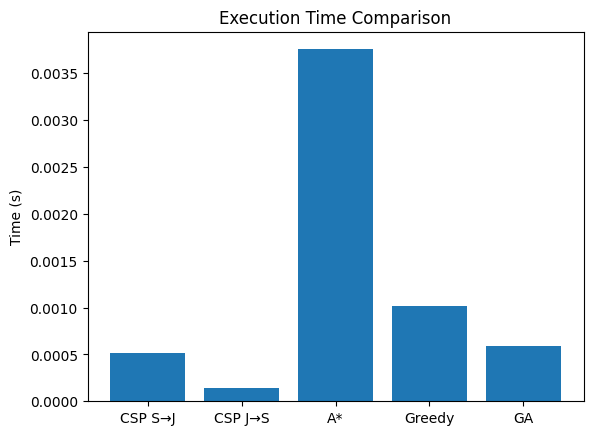

In [19]:
if __name__=='__main__':
    all_solver()